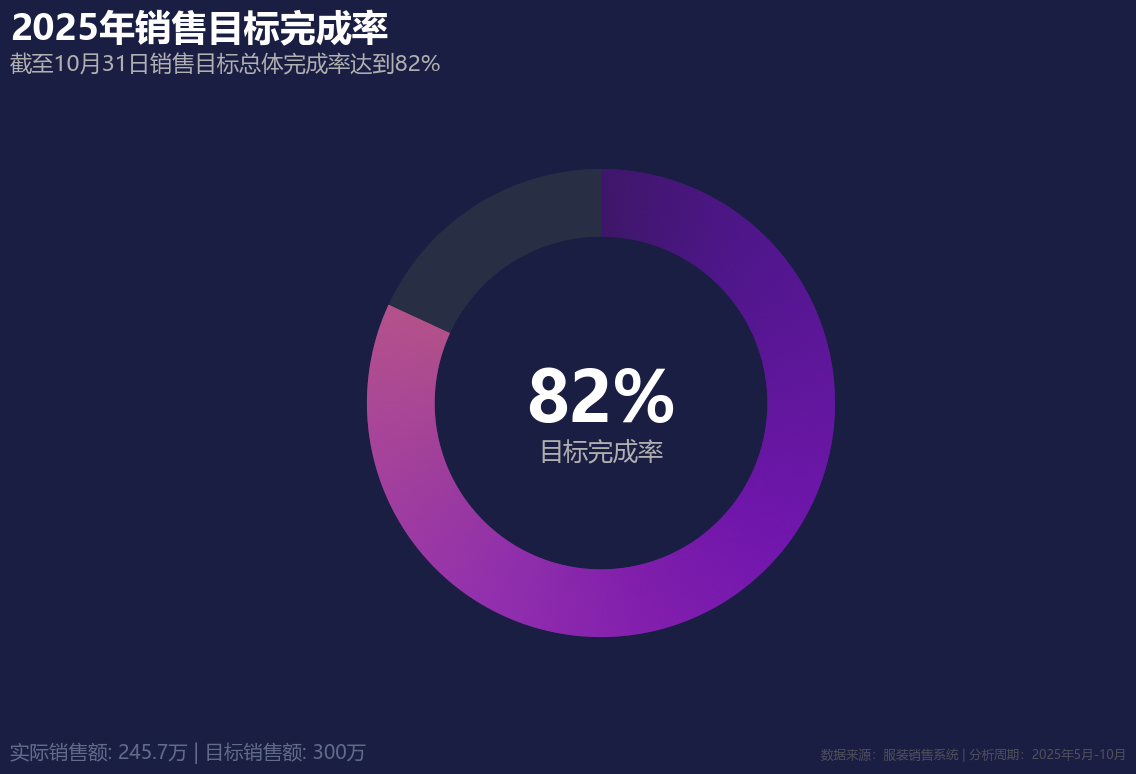

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.colors import LinearSegmentedColormap

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

try:
    # 数据计算与处理
    df_orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')

    if '已付金额' not in df_orders.columns or '下单时间' not in df_orders.columns:
        raise ValueError("订单数据中缺少必要列: '已付金额' 或 '下单时间'")

    actual_sales = df_orders['已付金额'].sum()
    target_sales = 3000000.0
    completion_rate = min(actual_sales / target_sales * 100, 100)
    latest_date = pd.to_datetime(df_orders['下单时间']).max().strftime('%m月%d日')

    # 创建紫色到粉色的柔和渐变色图
    colors = [
        (0.3, 0.05, 0.5),
        (0.4, 0.05, 0.7),
        (0.5, 0.05, 0.8),
        (0.6, 0.05, 0.9),
        (0.7, 0.1, 0.9),
        (0.8, 0.2, 0.9),
        (0.9, 0.3, 0.8),
        (1.0, 0.4, 0.7)
    ]
    cmap = LinearSegmentedColormap.from_list('purple_to_pink', colors, N=512)

    # 创建并显示单值圆环图
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='#1A1E43')
    center = (0.5, 0.5)
    outer_radius = 0.38
    ring_width = 0.11
    start_angle = 90
    total_angle = 360

    # 背景环
    bg_ring = Wedge(
        center, r=outer_radius, theta1=start_angle - total_angle, theta2=start_angle,
        width=ring_width, facecolor='#2C3345', edgecolor='none', alpha=0.8)
    ax.add_patch(bg_ring)

    # 进度环
    num_segments = 4090
    progress_angle = 360 * (completion_rate / 100.0)

    for i in range(num_segments):
        segment_angle = progress_angle * (i / num_segments)
        next_segment_angle = progress_angle * ((i + 1) / num_segments)
        angle1 = start_angle - next_segment_angle
        angle2 = start_angle - segment_angle
        color = cmap(i / num_segments)
        segment = Wedge(
            center, r=outer_radius,
            theta1=angle1, theta2=angle2,
            width=ring_width, facecolor=color, edgecolor='none', alpha=0.95)
        ax.add_patch(segment)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # 添加文本与说明
    ax.text(center[0], center[1], f"{completion_rate:.0f}%",
            va='center', ha='center', fontsize=50, color='white', fontweight='bold')
    ax.text(center[0], center[1] - 0.08, "目标完成率",
            va='center', ha='center', fontsize=18, color='#B0B0B0')

    plt.figtext(0.02, 0.95, "2025年销售目标完成率",
                ha='left', fontsize=26, color='white', fontweight='bold')
    plt.figtext(0.02, 0.91, f"截至{latest_date}销售目标总体完成率达到{completion_rate:.0f}%",
                ha='left', fontsize=16, color='#B0B0B0')

    actual_formatted = f"{actual_sales/10000:.1f}万"
    target_formatted = f"{target_sales/10000:.0f}万"
    plt.figtext(0.02, 0.05,
                f"实际销售额: {actual_formatted} | 目标销售额: {target_formatted}",
                ha='left', fontsize=14, color='#606C88')

    plt.figtext(0.95, 0.05,
                '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
                ha='right', fontsize=9, color='#666666', alpha=0.7)

    # 保存和显示图表
    plt.savefig('2025年销售目标完成率.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")

# 分析

- **目标完成率**：
  截至10月31日，销售目标的总体完成率达到82%。这一比率表明，企业在实现年度销售目标方面取得了显著进展。

- **实际销售额**：
  实际销售额为245.7万元，相对于设定的目标销售额300万元，已完成82%。这显示出企业在销售执行方面的有效性。

- **未完成部分**：
  剩余的18%（即约54.3万元）需要在未来的时间内完成，以实现全年销售目标。


# 结论

从销售目标完成率的分析来看，企业在2025年的销售表现是积极的，已经实现了超过80%的年度销售目标。这可能归因于有效的市场策略、产品竞争力以及良好的客户关系管理。然而，仍有18%的目标需要完成，企业需要继续优化销售策略，加强市场推广，并提高客户满意度，以确保全年目标的实现。